# Análisis exploratorio de incidencia delictiva en México

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/delitos.csv')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

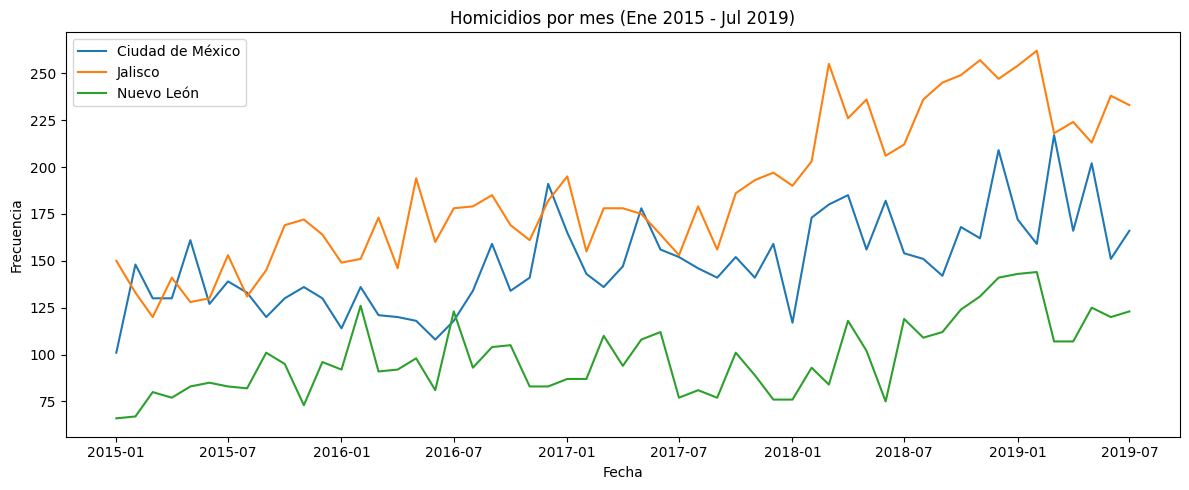

In [3]:
# Estados elegidos: Ciudad de México (9), Jalisco (14), Nuevo León (19)
estados = [9, 14, 19]
nombres = {9: 'Ciudad de México', 14: 'Jalisco', 19: 'Nuevo León'}

homicidios = df[
    (df['tipo_de_delito'] == 'Homicidio') &
    (df['clave_ent'].isin(estados)) &
    (df['fecha'] >= '2015-01-01') &
    (df['fecha'] <= '2019-07-01')
].copy()

homicidios['fecha'] = pd.to_datetime(homicidios['fecha'])

fig, ax = plt.subplots(figsize=(12, 5))

for clave in estados:
    datos_estado = homicidios[homicidios['clave_ent'] == clave].sort_values('fecha')
    ax.plot(datos_estado['fecha'], datos_estado['frecuencia'], label=nombres[clave])

ax.set_title('Homicidios por mes (Ene 2015 - Jul 2019)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [4]:
# 1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
colima_2018 = df[
    (df['entidad'] == 'Colima') &
    (df['tipo_de_delito'] == 'Homicidio') &
    (df['anio'] == 2018)
]['frecuencia'].sum()
print(f"1. Homicidios en Colima en 2018: {colima_2018:.0f}")

# 2. ¿Cuántos robos de vehículo automotor ha habido en el 2019?
robos_2019 = df[
    (df['tipo_de_delito'] == 'Robo') &
    (df['anio'] == 2019)
]['frecuencia'].sum()
print(f"2. Robos en 2019: {robos_2019:.0f}")

# 3. Suma de homicidios y feminicidios por año en toda la República
hom_fem = df[
    df['tipo_de_delito'].isin(['Homicidio', 'Feminicidio'])
].groupby(['anio', 'tipo_de_delito'])['frecuencia'].sum().unstack()
print("\n3. Homicidios y Feminicidios por año:")
print(hom_fem)

# 4. ¿En qué mes y en qué estado ha ocurrido el mayor número de feminicidios?
fem = df[df['tipo_de_delito'] == 'Feminicidio']
idx_max = fem['frecuencia'].idxmax()
fila_max = fem.loc[idx_max]
print(f"\n4. Mayor número de feminicidios en un mes:")
print(f"   Estado: {fila_max['entidad']}, Mes: {fila_max['nombre_mes']}, Año: {fila_max['anio']}, Frecuencia: {fila_max['frecuencia']:.0f}")

# 5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?
fem_anio_estado = df[
    df['tipo_de_delito'] == 'Feminicidio'
].groupby(['anio', 'entidad'])['frecuencia'].sum().reset_index()
idx_max5 = fem_anio_estado['frecuencia'].idxmax()
fila_max5 = fem_anio_estado.loc[idx_max5]
print(f"\n5. Mayor número de feminicidios por año y estado:")
print(f"   Estado: {fila_max5['entidad']}, Año: {fila_max5['anio']}, Frecuencia: {fila_max5['frecuencia']:.0f}")

1. Homicidios en Colima en 2018: 726
2. Robos en 2019: 766096

3. Homicidios y Feminicidios por año:
tipo_de_delito  Feminicidio  Homicidio
anio                                  
2015                  413.0    31331.0
2016                  608.0    35410.0
2017                  744.0    41324.0
2018                  899.0    44486.0
2019                  944.0    44878.0
2020                  947.0    43276.0
2021                  981.0    43979.0
2022                  961.0    42884.0
2023                  832.0    42014.0
2024                  401.0    21906.0

4. Mayor número de feminicidios en un mes:
   Estado: México, Mes: julio, Año: 2020, Frecuencia: 19

5. Mayor número de feminicidios por año y estado:
   Estado: México, Año: 2020, Frecuencia: 151


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

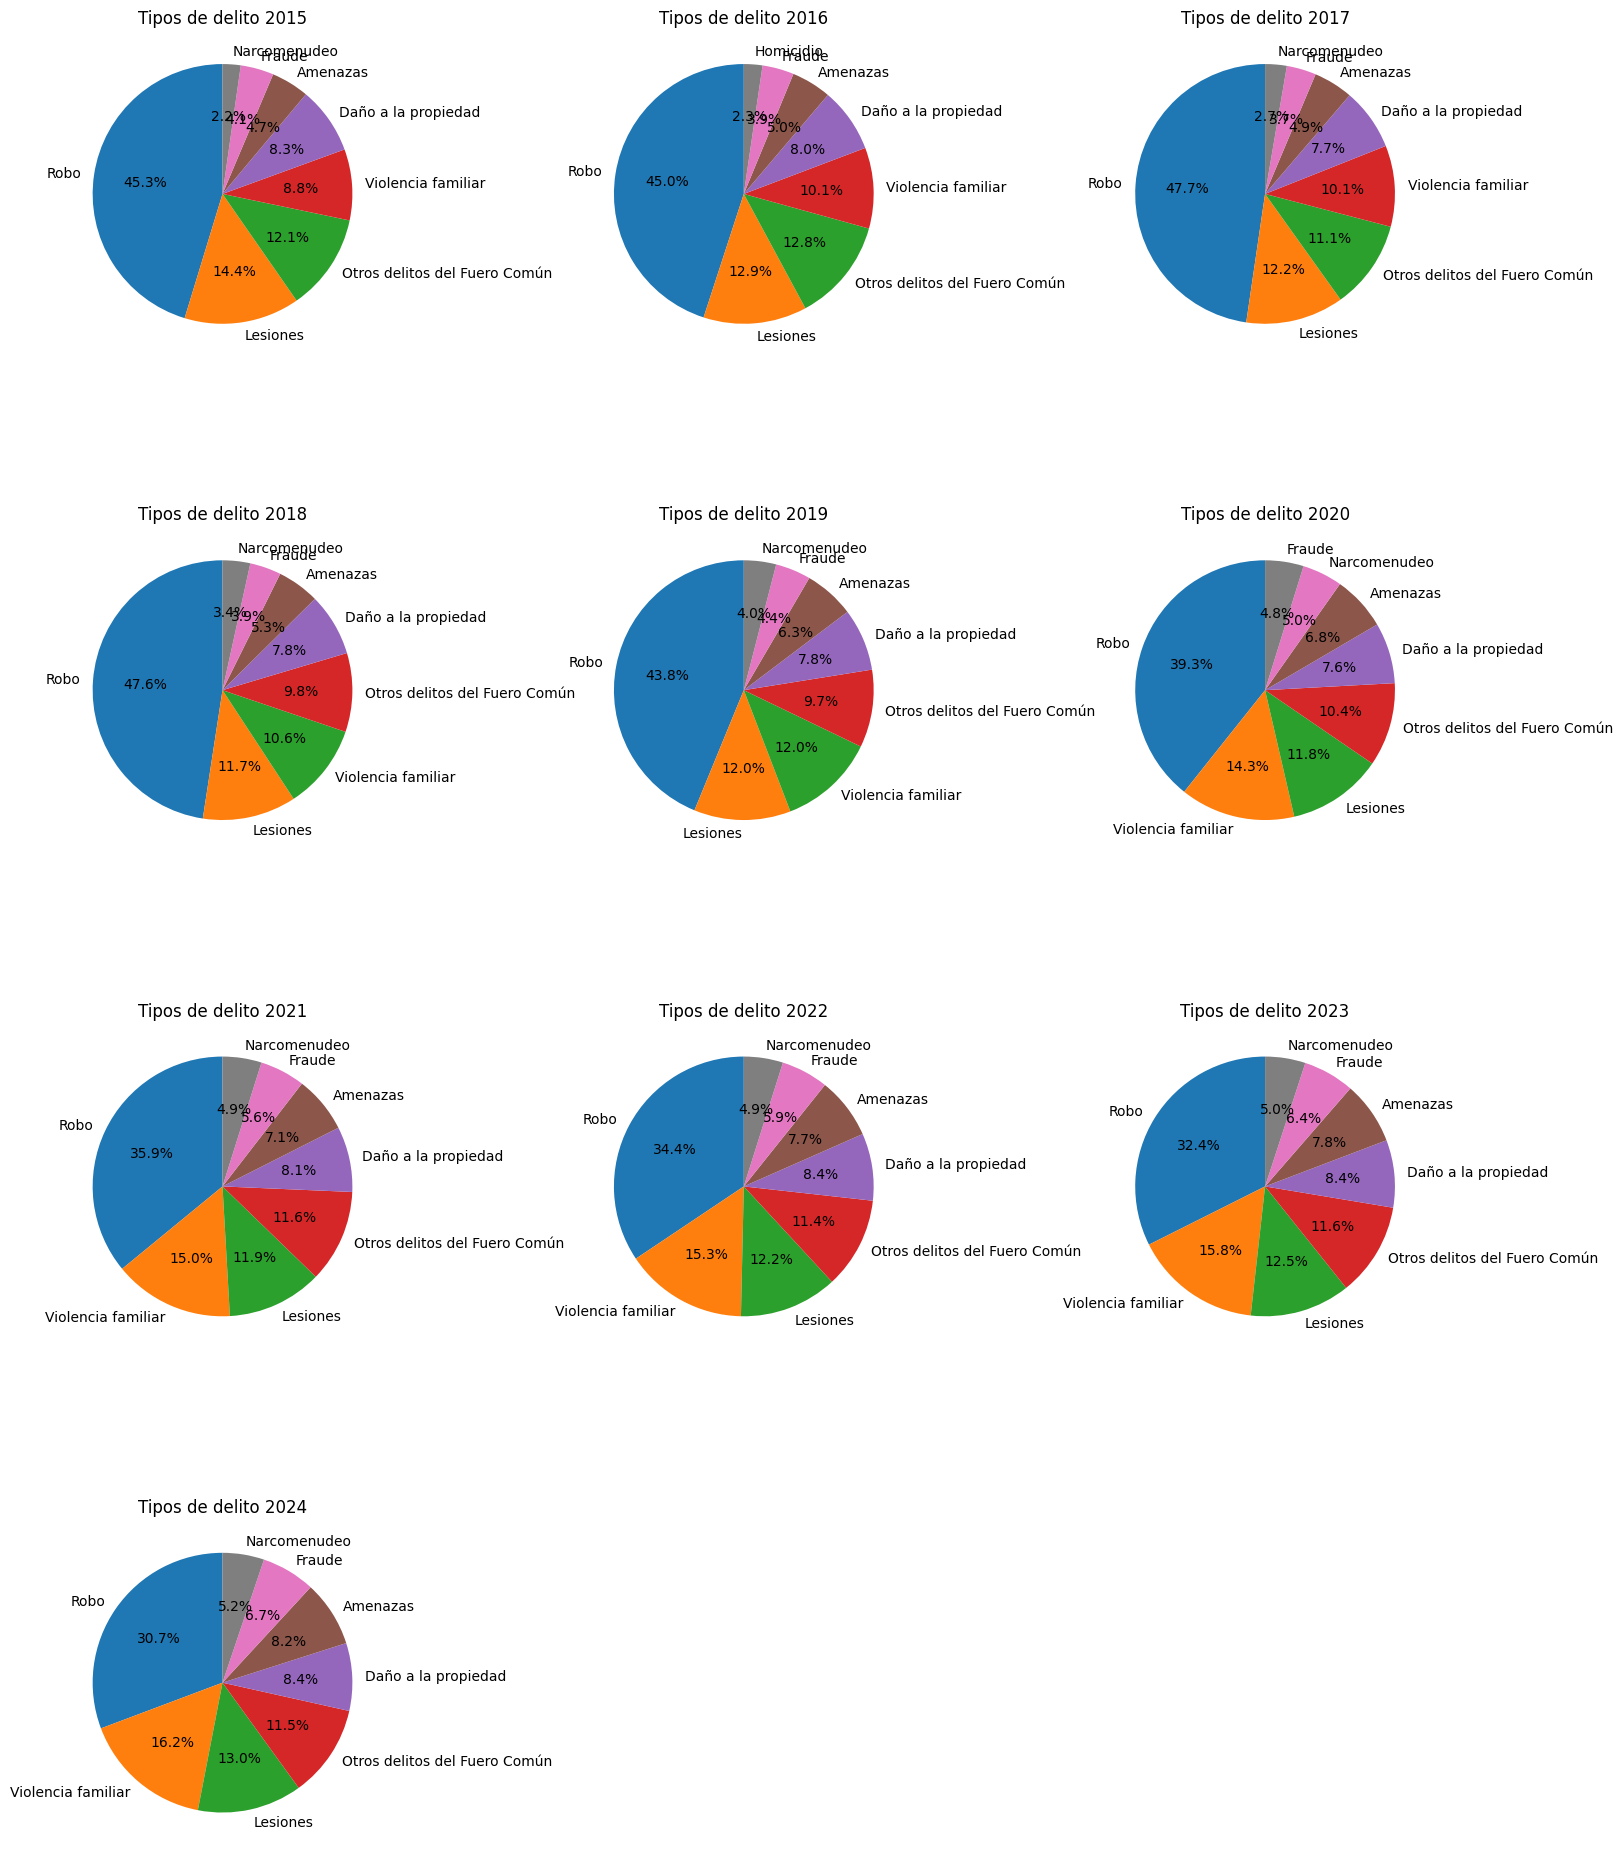

In [5]:
anios = sorted(df['anio'].unique())
n = len(anios)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i, anio in enumerate(anios):
    datos_anio = df[df['anio'] == anio].groupby('tipo_de_delito')['frecuencia'].sum()
    # Solo mostrar los 8 tipos con más delitos para que la gráfica sea legible
    datos_anio = datos_anio.nlargest(8)
    axes[i].pie(datos_anio, labels=datos_anio.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Tipos de delito {anio}')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [6]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


In [7]:
# Unir delitos con población usando clave de entidad
df_tasa = df.merge(pobs, left_on='clave_ent', right_on='clave_entidad')

# Calcular tasa mensual por 100,000 habitantes
df_tasa['tasa'] = (df_tasa['frecuencia'] / df_tasa['poblacion']) * 100_000

# Calcular tasa anualizada
df_tasa['tasa_anualizada'] = df_tasa['tasa'] * 12

df_tasa[['entidad_x', 'tipo_de_delito', 'nombre_mes', 'anio', 'frecuencia', 'poblacion', 'tasa', 'tasa_anualizada']].head()

,entidad_x,tipo_de_delito,nombre_mes,anio,frecuencia,poblacion,tasa,tasa_anualizada
0,Aguascalientes,Aborto,abril,2015,0.0,1312544.0,0.000000,0.000000
1,Aguascalientes,Aborto,agosto,2015,0.0,1312544.0,0.000000,0.000000
2,Aguascalientes,Aborto,diciembre,2015,0.0,1312544.0,0.000000,0.000000
3,Aguascalientes,Aborto,enero,2015,0.0,1312544.0,0.000000,0.000000
4,Aguascalientes,Aborto,febrero,2015,3.0,1312544.0,0.228564,2.742765


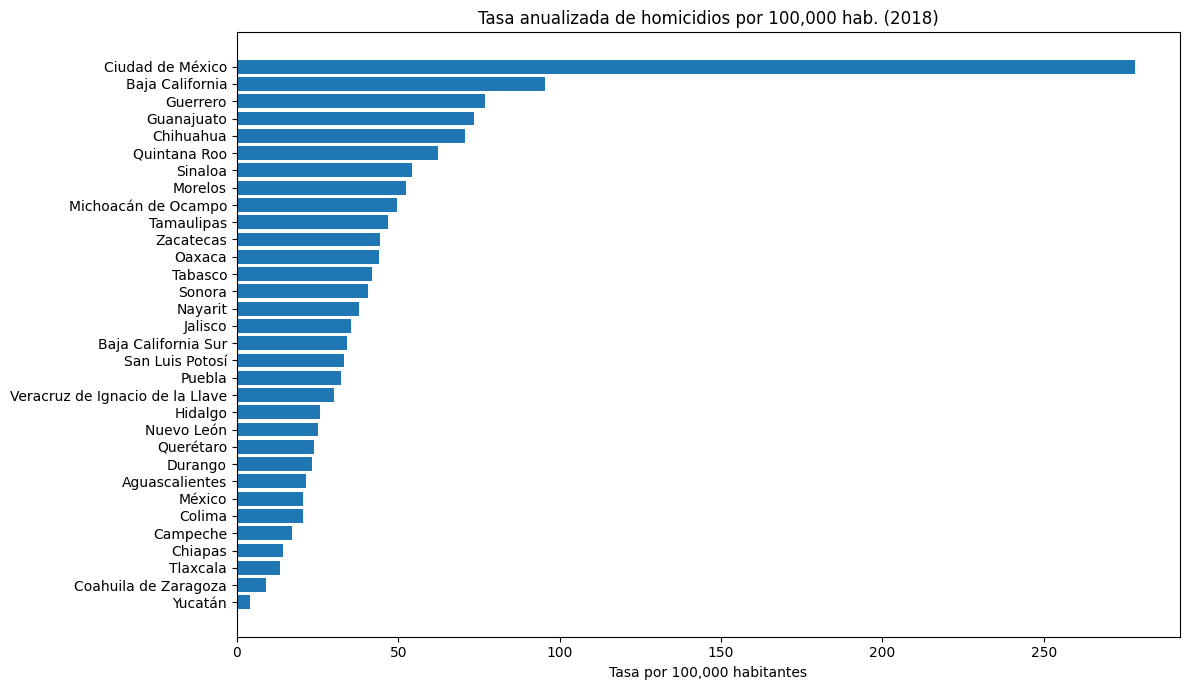

In [8]:
# Tasa anualizada de homicidios por estado en 2018
tasa_hom_2018 = df_tasa[
    (df_tasa['tipo_de_delito'] == 'Homicidio') &
    (df_tasa['anio'] == 2018)
].groupby('entidad_x')['tasa_anualizada'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(tasa_hom_2018.index, tasa_hom_2018.values)
ax.set_title('Tasa anualizada de homicidios por 100,000 hab. (2018)')
ax.set_xlabel('Tasa por 100,000 habitantes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()